# CAB420, Classification, Additional Example 2: Additional Example: Classifier Parameters and Decision Boundaries
Dr Simon Denman (s.denman@qut.edu.au)

## Overview
This is essentially an appendix to ``CAB420_Classification_Example_2_Multi_Class_Classification.ipynb``, where we look at how accuracy changes with the various classification parameters. Don't look at this without understanding that main example. This content has been thrown in here to simply avoid that other example growing too much.

Some quite things to consider with respect to this example are:
* We're using this to visualise trends. Whilst we are looking at this on a particular dataset, focus on the high level trend - i.e. what happens as a parameter gets bigger or smaller
* Where things are a bit weird and don't increase or decrease smoothly, we'll try to explain why, but again keep in mind on that other datasets you may see other weird things - maybe similar to what we see here, maybe not
* If in doubt about the patterns you see here, ask. Also you are encouraged to adapt this code to other datasets, or change some parameters like the use of class weights, or compare F1 scores rather than accuracies.

In [1]:
import pandas
import numpy
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC, NuSVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from scipy.stats import norm
from sklearn import tree
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# warning filtering for SVM fitting. I'm going to limit the number of iterations that SVMs fit for, without this the screen will be filled with warnings, I want to avoid this.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# a large value, represnting the hard margin SVM case
inf = 1e250

## The Data

See the main example for what's going on here - this is the same data pre-processing, just all in one block and without the visualisations and detail on what's going on.

In [2]:
#load data
craft_beer = pandas.read_csv('../data/craft-cans/beers.csv')

# remove beers with no style or name
craft_beer = craft_beer[~craft_beer['style'].isna()]
craft_beer = craft_beer[~craft_beer['name'].isna()]

# make style a categorical
craft_beer['style'] = pandas.Categorical(craft_beer['style'])
counts = craft_beer['style'].value_counts()

# remove some beers that are rare
threshold = 50
to_remove = counts[counts <= threshold].index

# remove the beers, then remove the now unloved categories
craft_beer = craft_beer[~craft_beer['style'].isin(to_remove)]
craft_beer['style'] = craft_beer['style'].cat.remove_unused_categories()
craft_beer.reset_index(inplace=True)

# store as list of names
names = []
for n in craft_beer['name']:
    # strip out punctuation
    names.append(n.translate(str.maketrans('', '', string.punctuation)))
    
# store as list of lists of words
names_tokens = []
for n in names:
    # break into tokens
    tokens = re.sub(r"[^a-z0-9]+", " ", n.lower()).split()
    names_tokens.append(tokens)

# train the model
embedding_size = 50
# note that we're going to include every word by setting min_count to 1, this means that even if the word only 
# occurs once, it will be in our model. This is perhaps not the best approach, but we have too small of a corpus
# to go ruling rare words out (they're all rare for us - which does again raise those questions of if we should 
# train our own model or not)
word_model = Word2Vec(sentences=names_tokens, vector_size=embedding_size, window=3, min_count=1, workers=4, sg=0)

max_words = 6
X = []
X_names = []
Y = []
for i,n in enumerate(names_tokens):    
    v = numpy.zeros(embedding_size*max_words)
    if (len(n) <= 6):
        for j,w in enumerate(n):
            v[j*embedding_size:(j+1)*embedding_size] = word_model.wv[w]
        X.append(v)
        Y.append(craft_beer['style'][i])
        X_names.append(names[i])

X_train, X_test, X_train_names, X_test_names, Y_train, Y_test = train_test_split(X, X_names, Y, test_size=0.3, random_state=1)

print(numpy.shape(X_train))
print(numpy.shape(X_train_names))
print(numpy.shape(Y_train))
print(numpy.shape(X_test))
print(numpy.shape(X_test_names))
print(numpy.shape(Y_test))

(938, 300)
(938,)
(938,)
(403, 300)
(403,)
(403,)


## K-Nearest Neighbours

We'll consider three parameters:
* K, i.e. the number of neighbours we're checking
* The distance metric we're using to find neighbours
* The weighting scheme we use to weights neighbours

To avoid 3D plots, we'll look at these in pairs. For each configuration, we'll get the overall accuracy and the balanced accuracy that takes class imbalance into consideration. We'll get both as we have considerable class imbalance in this dataset, so it's worth looking at how both are impacted.

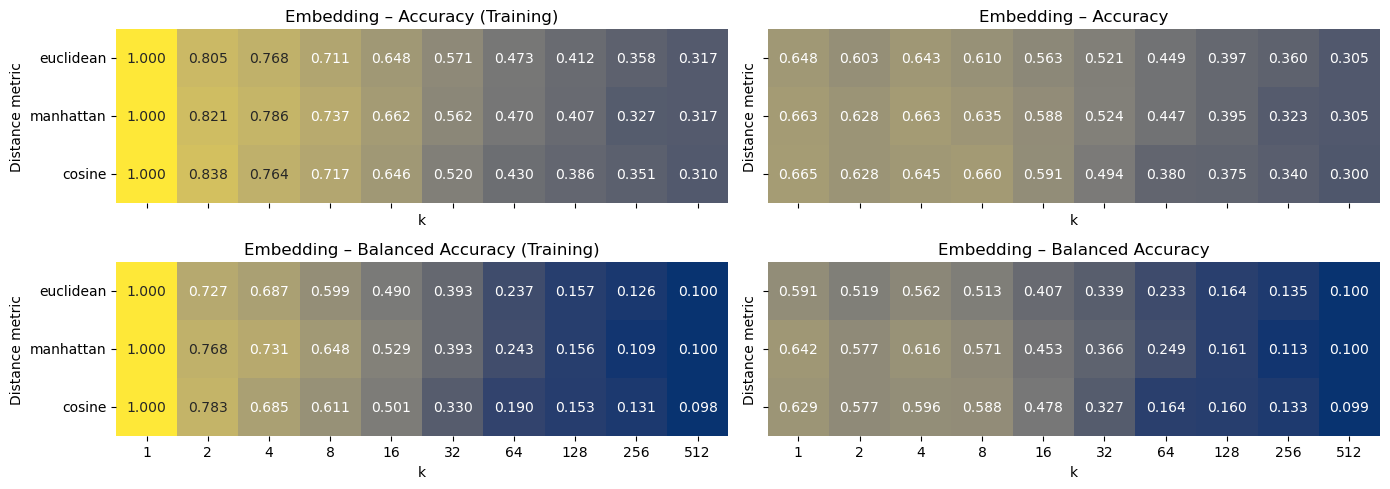

In [3]:
ks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
metrics = ['euclidean', 'manhattan', 'cosine']

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(metrics), len(ks)))
embedding_bal_acc_grid_train = numpy.zeros((len(metrics), len(ks)))
embedding_acc_grid = numpy.zeros((len(metrics), len(ks)))
embedding_bal_acc_grid = numpy.zeros((len(metrics), len(ks)))

for i, metric in enumerate(metrics):
    for j, k in enumerate(ks):
        # brute works reliably across metrics
        model_embedding = KNeighborsClassifier(n_neighbors=k, metric=metric, algorithm='brute').fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=metrics, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('k')
axes[0,0].set_ylabel('Distance metric')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=metrics, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('k')
axes[0,1].set_ylabel('Distance metric')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=metrics, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('k')
axes[1,0].set_ylabel('Distance metric')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=metrics, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('k')
axes[1,1].set_ylabel('Distance metric')

plt.tight_layout()
plt.show()

The above considers how performance changes with the distance metric, and K. Things to note here:
* Training accuracy is perfect at K=1. This is expected and is not overfitting. Rather we are looking for 1 neighbour. Because we are evaluating performance on the training set, when we search for a neighbour for a point, we find that exact point as the closest neighobur.
* As K increases, beyond some point performance drops. As K becomes larger than the number of samples in our minority classes, we lose the ability to recognise those classes. This is why we see this more in the balanced accuracy case, those the pattern is evident for both. You will see this in the majority of setting with KNN, but the point at which things drop will vary, and how much they drop will depend on the class distribution
* In all settings K=1 is best. This is not typical, and suggests that each of our points is quite unique (which they are). With more data, we'd expect this to change. The more data you have, the larger the optimal value of K is likely to be, and the less diverse the data within each class, the larger the optimal value of K is likely to be.
* There is no big difference between distance metrics here. In some specific cases, you will see distance metric make a huge difference, in others it will make little impact. What impact you see depends on the nature of the data. Here, we're using 300-D embeddings that have all been normalised - so the angle between the vectors (cosine distance) is meaningful, as is the euclidean or manhattan distance. As such, any metric can be seen as valid here, and all work similarly.

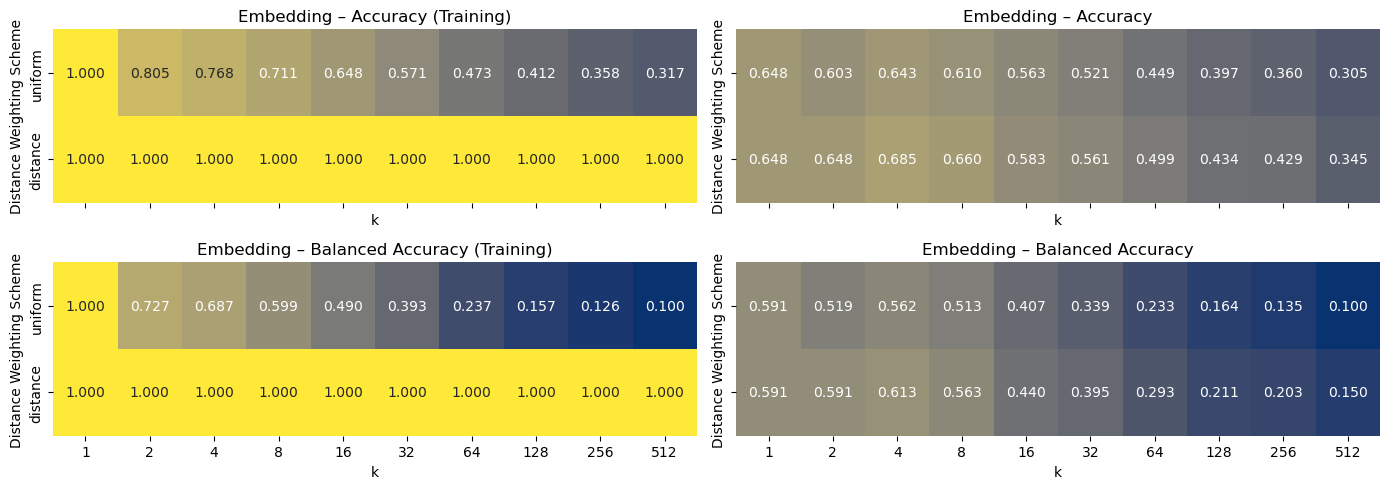

In [4]:
ks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
weights = ['uniform', 'distance']

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(weights), len(ks)))
embedding_bal_acc_grid_train = numpy.zeros((len(weights), len(ks)))
embedding_acc_grid = numpy.zeros((len(weights), len(ks)))
embedding_bal_acc_grid = numpy.zeros((len(weights), len(ks)))

for i, weight in enumerate(weights):
    for j, k in enumerate(ks):
        # brute works reliably across metrics
        model_embedding = KNeighborsClassifier(n_neighbors=k, weights=weight, algorithm='brute').fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=weights, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('k')
axes[0,0].set_ylabel('Distance Weighting Scheme')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=weights, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('k')
axes[0,1].set_ylabel('Distance Weighting Scheme')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=weights, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('k')
axes[1,0].set_ylabel('Distance Weighting Scheme')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=ks, yticklabels=weights, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('k')
axes[1,1].set_ylabel('Distance Weighting Scheme')

plt.tight_layout()
plt.show()

Above we look at weighting schemes and how these change with K. Some things to note:
* With distance based weighting, on the training set accuracy is always perfect. Again, this is not overfitting. When we look for neighbours to a point, because we are evalating on the training set the closest neighbour is the exact point, so the distance between our query point and our best neighbour is 0.
* We see the same pattern of performance falling away as K gets too big, but the distance weights tempers this somewhat as nearby points have a larger influence, so it takes longer for these to be drowned out
* With the distance weighting we see increasing K up to some point (in this case 8) leads to a performance gain. This broad trend (performance increasing at first as K increases, then falling away as K becomes too big) is typical
* With the distance weighting scheme performance is better. This is caused by the minority classes, small dataset, and spread out nature of the points. 

## Multi-Class SVMs

We'll consider:
* C
* The Kernel (linear, rbf, polynomial)
* Kernel parameters

I'm not considering the differences between One vs All or One vs The Rest; or the impact of things like Class Weights. Try these youselves.

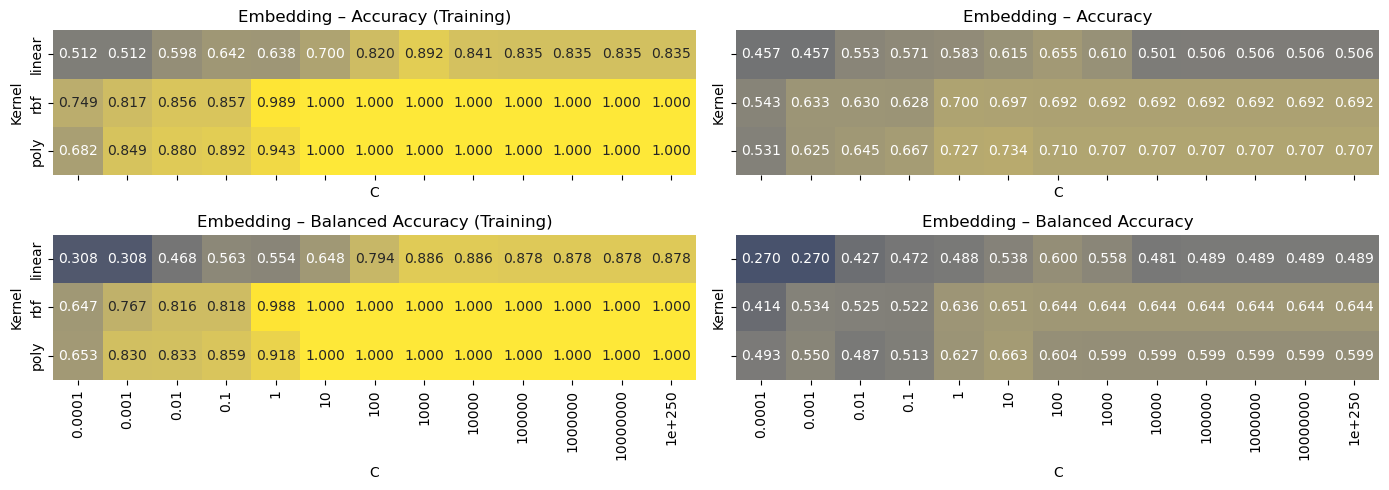

In [5]:
cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, inf]
kernels = ['linear', 'rbf', 'poly']

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(kernels), len(cs)))
embedding_bal_acc_grid_train = numpy.zeros((len(kernels), len(cs)))
embedding_acc_grid = numpy.zeros((len(kernels), len(cs)))
embedding_bal_acc_grid = numpy.zeros((len(kernels), len(cs)))

for i, k in enumerate(kernels):
    for j, c in enumerate(cs):
        # could switch to OneVsOneClassifier, could enable class_weight='balanced'        
        model_embedding = OneVsRestClassifier(SVC(C = c, kernel=k, max_iter=1000)).fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=kernels, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('C')
axes[0,0].set_ylabel('Kernel')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=kernels, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('C')
axes[0,1].set_ylabel('Kernel')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=kernels, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('C')
axes[1,0].set_ylabel('Kernel')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=kernels, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('C')
axes[1,1].set_ylabel('Kernel')

plt.tight_layout()
plt.show()

Some things to note:
* C is critical. If C is too small, performance sucks because the model underfits. If C is too big, performance sucks because the model overfits. In all cases we see performance on the test set increase as we increase C up to some point, and beyond this performance drops.
* The optimal C changes for each kernel, and may also vary depending on what we are seeking to maximise (different C's maximise RBF performance depending on what criteria we use).
* Performance across kernels varies. Here, the polynomial works best. Which is best will vary for each problem.

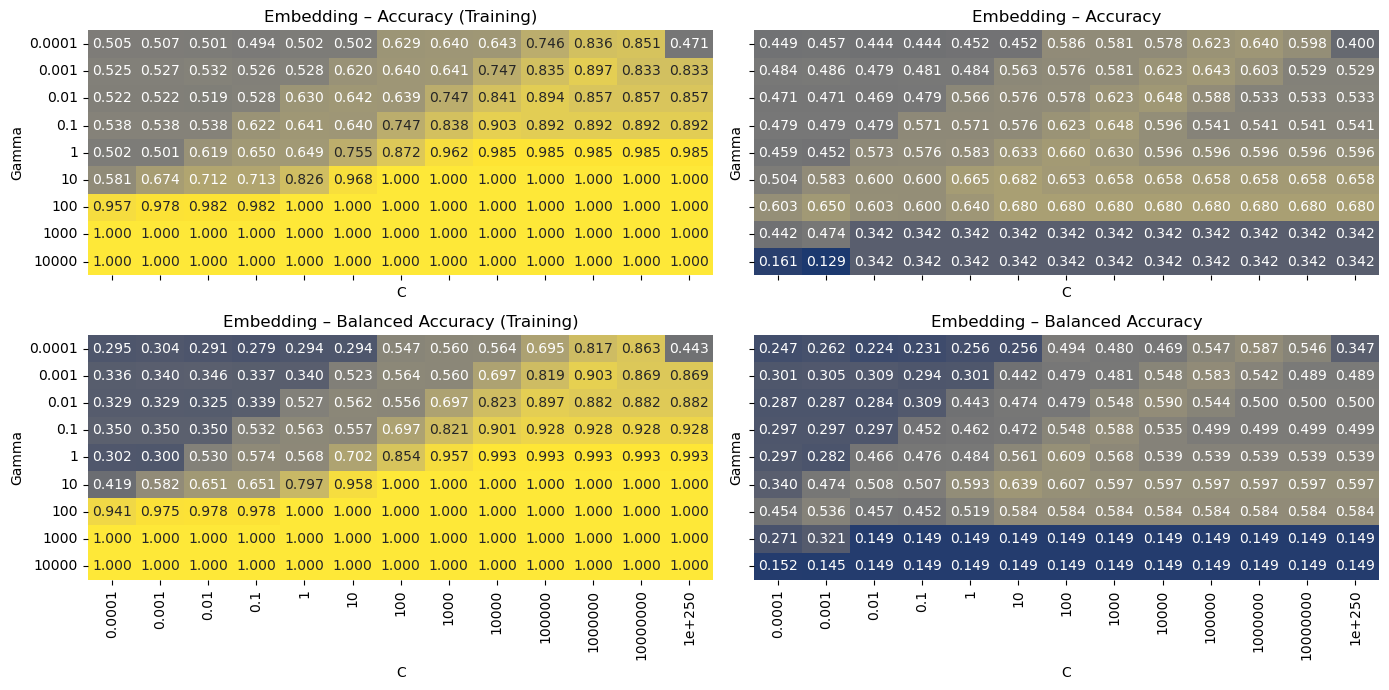

In [6]:
cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, inf]
gammas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(gammas), len(cs)))
embedding_bal_acc_grid_train = numpy.zeros((len(gammas), len(cs)))
embedding_acc_grid = numpy.zeros((len(gammas), len(cs)))
embedding_bal_acc_grid = numpy.zeros((len(gammas), len(cs)))

for i, g in enumerate(gammas):
    for j, c in enumerate(cs):
        # brute works reliably across metrics
        model_embedding = OneVsRestClassifier(SVC(C = c, kernel='rbf', gamma=g, max_iter=1000)).fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=gammas, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('C')
axes[0,0].set_ylabel('Gamma')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=gammas, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('C')
axes[0,1].set_ylabel('Gamma')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=gammas, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('C')
axes[1,0].set_ylabel('Gamma')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=gammas, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('C')
axes[1,1].set_ylabel('Gamma')

plt.tight_layout()
plt.show()

Gamma defines how far the influence of a single training example extends, with low values meaning 'far' and high values meaning 'close'. High values of gamma will create more complex class boundaries (which leads to severe overfitting), while lower values will lead to smoother boundaries.
* The optimal gamma varies with C. These must be considered in combination when selecting parameters
* Gamma shows a similar pattern to C, we see performnace increase as gamma increases up to some point, and then performance falls away. That drop off however is quite dramatic compared to C and massive overfitting is evident once the value of gamme gets too big.

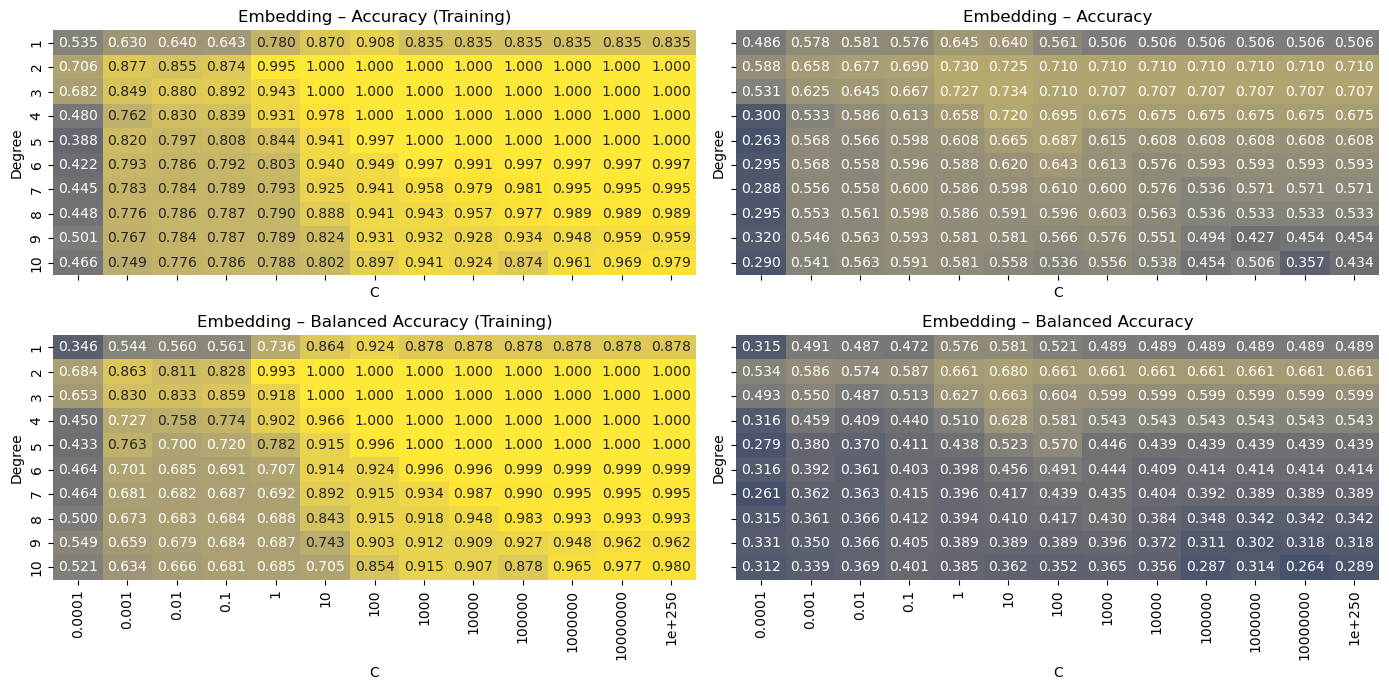

In [8]:
cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, inf]
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(degrees), len(cs)))
embedding_bal_acc_grid_train = numpy.zeros((len(degrees), len(cs)))
embedding_acc_grid = numpy.zeros((len(degrees), len(cs)))
embedding_bal_acc_grid = numpy.zeros((len(degrees), len(cs)))

for i, d in enumerate(degrees):
    for j, c in enumerate(cs):
        # brute works reliably across metrics
        model_embedding = OneVsRestClassifier(SVC(C = c, kernel='poly', degree=d, max_iter=1000)).fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=degrees, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('C')
axes[0,0].set_ylabel('Degree')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=degrees, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('C')
axes[0,1].set_ylabel('Degree')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=degrees, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('C')
axes[1,0].set_ylabel('Degree')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=cs, yticklabels=degrees, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('C')
axes[1,1].set_ylabel('Degree')

plt.tight_layout()
plt.show()

The degree determines the complexity of the polynomial kernel. Higher degrees are more complex (i.e. higher order polynomial. With respect to this we see:
* The best C varies for different order kernels, similar to gamma and C with the RBF kernel.
* As the degree increases, performance gets worse. Here we have a degree 1 kernel (i.e. linear), and we see that increasing this up to 3 improves performance, afterwhich is drops away. Higher order kernels are more prone to overfitting (and/or failing to converge), which is why performance falls away. The point at which the kernel becomes too complex varies between datasets, but the trend of larger kernels being harder to fit will hold.

## Random Forests 

Here, we'll consider:
* Tree depth
* Number of estimators

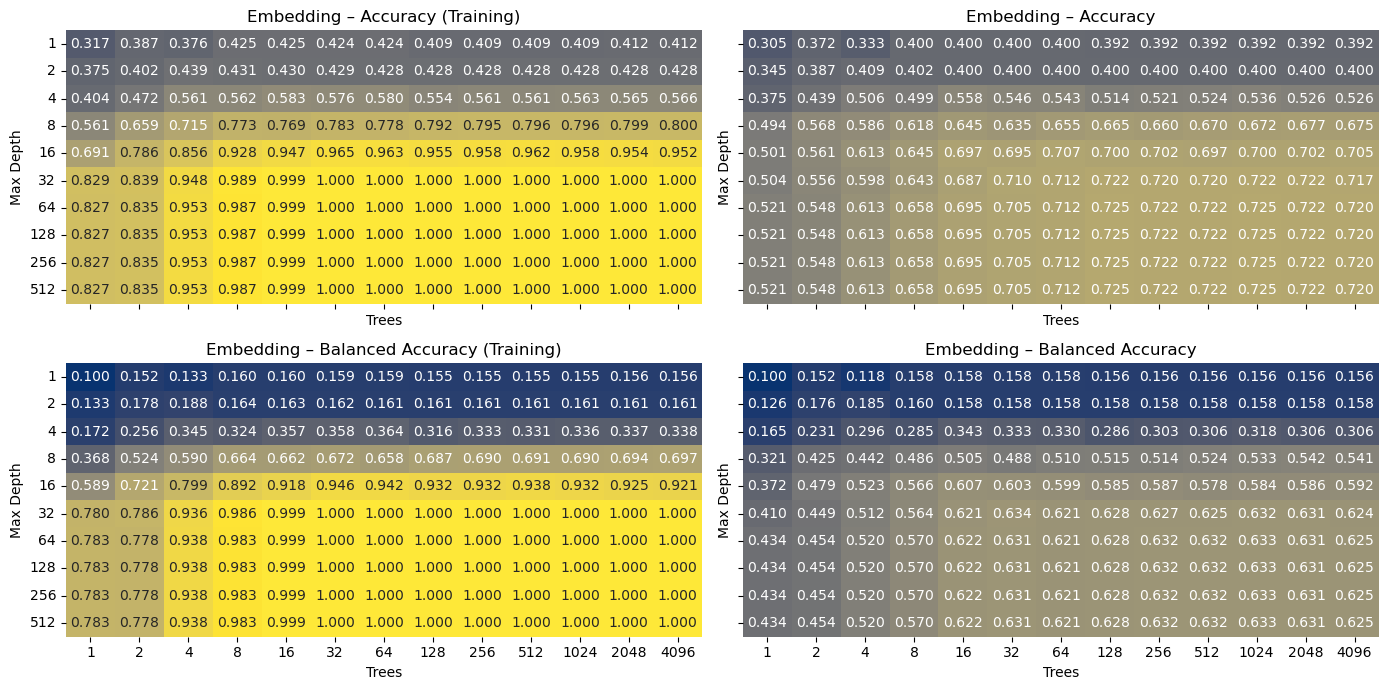

In [9]:
trees = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
depth = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

# Result arrays: shape = (n_metrics, n_ks)
embedding_acc_grid_train = numpy.zeros((len(depth), len(trees)))
embedding_bal_acc_grid_train = numpy.zeros((len(depth), len(trees)))
embedding_acc_grid = numpy.zeros((len(depth), len(trees)))
embedding_bal_acc_grid = numpy.zeros((len(depth), len(trees)))

for i, d in enumerate(depth):
    for j, t in enumerate(trees):
        # brute works reliably across metrics
        model_embedding = RandomForestClassifier(n_estimators=t, max_depth=d, random_state=0).fit(X_train, Y_train)
        embedding_acc_grid_train[i, j] = accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_bal_acc_grid_train[i, j] = balanced_accuracy_score(Y_train, model_embedding.predict(X_train))
        embedding_acc_grid[i, j] = accuracy_score(Y_test, model_embedding.predict(X_test))
        embedding_bal_acc_grid[i, j] = balanced_accuracy_score(Y_test, model_embedding.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

sns.heatmap(embedding_acc_grid_train, ax=axes[0,0],
    annot=True, fmt=".3f", xticklabels=trees, yticklabels=depth, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,0].set_title('Embedding – Accuracy (Training)')
axes[0,0].set_xlabel('Trees')
axes[0,0].set_ylabel('Max Depth')

sns.heatmap(embedding_acc_grid, ax=axes[0,1],
    annot=True, fmt=".3f", xticklabels=trees, yticklabels=depth, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[0,1].set_title('Embedding – Accuracy')
axes[0,1].set_xlabel('Trees')
axes[0,1].set_ylabel('Max Depth')

sns.heatmap(embedding_bal_acc_grid_train, ax=axes[1,0],
    annot=True, fmt=".3f", xticklabels=trees, yticklabels=depth, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,0].set_title('Embedding – Balanced Accuracy (Training)')
axes[1,0].set_xlabel('Trees')
axes[1,0].set_ylabel('Max Depth')

sns.heatmap(embedding_bal_acc_grid, ax=axes[1,1],
    annot=True, fmt=".3f", xticklabels=trees, yticklabels=depth, cmap='cividis',
    vmin=0.0, vmax=1.0, cbar=False)
axes[1,1].set_title('Embedding – Balanced Accuracy')
axes[1,1].set_xlabel('Trees')
axes[1,1].set_ylabel('Max Depth')

plt.tight_layout()
plt.show()

Things to note:
* More trees is better up to some point, at which performance plateaus. Note that performance doesn't drop as we keep increasing trees, it just flatlines (if you're looking at the small bit of variation here around this and thinking "that's not flat, it's moving a bit", that's just the random seed). What is happening is that once we've got enough trees we have enough diversity in the forest, and any further trees simply are not contributing anything knew. For us, this occurs at $128-256$, but the point this happens will vary the different dataests. When selecting the number of trees we want to select this point, the point at which we stop seeing improvement as we add more trees.
* As we increase depth, we increase performance up to some point. Here, we don't see the performance drop we'd often see as keep increasing depth too far. Depth would usually behave somewhat like C in an SVM, in that if it's too low we underfit and can't separate the classes, but if it's too big we overfit.